# Nigerian SME Segmentation - Modelling

**Dataset:** `data/processed/sme_clean.csv` - 1,043 firms, 21 features  
**Goal:** Identify meaningful SME segments using unsupervised learning  
**Methods:** StandardScaler, PCA, K-Means, Hierarchical Clustering  

> **Reproducibility note:** Segment names are inferred dynamically from cluster profiles  
> each run. With the same data and `random_state=42`, results are stable across runs.

---

## 1. Imports and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/processed/sme_clean.csv')

print(df.shape)
df.head()

(1043, 21)


,l1,k3a,k3bc,k3f,d3c,d12b,b5,b7,k82a,b8,h1,h8,c22b,e6,e11,b4,k30,c30a,j30a,e30,sales_growth
0,3.258097,70.0,10.0,20.0,0.0,0.0,2016.0,2.564949,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,3.0,1.0,0.628609
1,3.433987,100.0,0.0,0.0,0.0,0.0,2005.0,3.044522,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.223144
2,2.079442,60.0,0.0,20.0,0.0,0.0,2008.0,2.890372,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,3.0,2.0,2.0,0.310155
3,2.397895,60.0,0.0,0.0,0.0,0.0,2012.0,2.772589,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,3.0,1.0,4.0,0.916291
4,2.197225,100.0,0.0,0.0,0.0,100.0,1969.0,2.772589,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,3.0,2.0,-0.154151


## 2. Feature Scaling

Before any distance-based algorithm, all features must be on the same scale.  
StandardScaler brings every feature to mean=0 and std=1.

Without this, features with the largest raw variance would dominate distance  
calculations regardless of their actual importance. Even after log-transforming  
skewed features in EDA, the raw ranges still differ enough to cause problems.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# wrap back in a dataframe for readability
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print(X_scaled.shape)
X_scaled.describe().round(2)

(1043, 21)


,l1,k3a,k3bc,k3f,d3c,d12b,b5,b7,k82a,b8,h1,h8,c22b,e6,e11,b4,k30,c30a,j30a,e30,sales_growth
count,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00
mean,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.00,-2.56,-0.28,-0.54,-0.16,-0.55,-7.19,-3.06,-0.39,-0.36,-0.58,-0.44,-0.78,-0.44,-1.09,-0.55,-1.56,-2.16,-1.48,-1.35,-6.89
25%,-0.74,-0.77,-0.28,-0.54,-0.16,-0.55,-0.38,-0.68,-0.39,-0.36,-0.58,-0.44,-0.78,-0.44,-1.09,-0.55,-0.82,-0.48,-0.60,-0.51,-0.28
50%,-0.26,0.31,-0.28,-0.54,-0.16,-0.55,0.33,0.01,-0.39,-0.36,-0.58,-0.44,-0.78,-0.44,0.91,-0.55,-0.07,0.36,0.28,-0.51,-0.06
75%,0.52,1.03,-0.28,0.19,-0.16,0.24,0.68,0.76,-0.39,-0.36,1.72,-0.44,1.28,-0.44,0.91,-0.55,0.68,0.36,1.17,0.34,0.19
max,4.23,1.03,10.93,6.72,12.65,3.41,1.31,2.14,2.58,2.77,1.72,2.29,1.28,2.27,0.91,1.83,1.43,1.20,2.05,2.03,8.83


## 3. PCA - Dimensionality Reduction

With 21 features, PCA can potentially reduce noise and collinearity before  
clustering. We run full PCA first to inspect the explained variance curve  
before deciding how many components to keep.

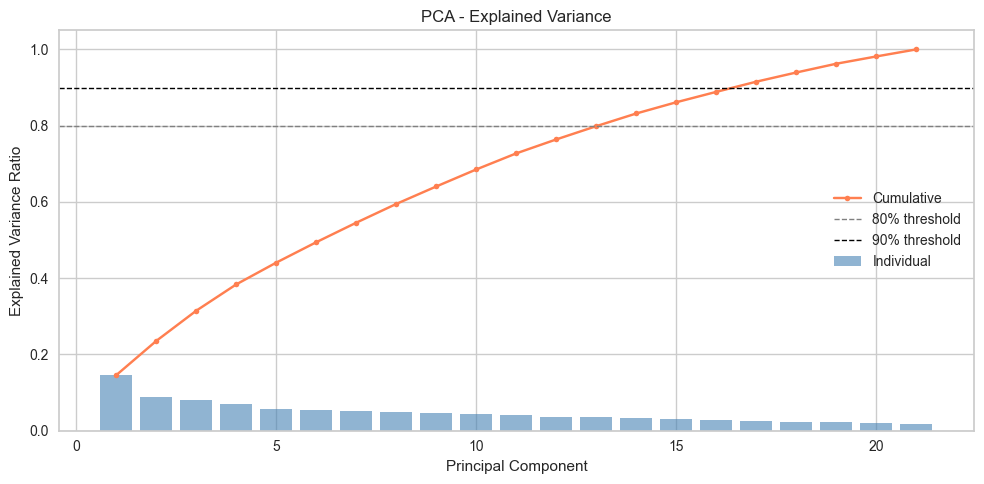

PC01: 0.146 individual | 0.146 cumulative
PC02: 0.090 individual | 0.235 cumulative
PC03: 0.079 individual | 0.315 cumulative
PC04: 0.069 individual | 0.384 cumulative
PC05: 0.057 individual | 0.441 cumulative
PC06: 0.054 individual | 0.494 cumulative
PC07: 0.051 individual | 0.546 cumulative
PC08: 0.049 individual | 0.595 cumulative
PC09: 0.046 individual | 0.641 cumulative
PC10: 0.045 individual | 0.685 cumulative
PC11: 0.042 individual | 0.727 cumulative
PC12: 0.037 individual | 0.764 cumulative
PC13: 0.035 individual | 0.799 cumulative
PC14: 0.033 individual | 0.832 cumulative
PC15: 0.029 individual | 0.861 cumulative
PC16: 0.027 individual | 0.889 cumulative
PC17: 0.027 individual | 0.915 cumulative
PC18: 0.024 individual | 0.939 cumulative
PC19: 0.023 individual | 0.962 cumulative
PC20: 0.019 individual | 0.982 cumulative
PC21: 0.018 individual | 1.000 cumulative


In [4]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained)+1), explained, alpha=0.6, 
       color='steelblue', label='Individual')
ax.plot(range(1, len(cumulative)+1), cumulative, 
        color='coral', marker='o', markersize=4, label='Cumulative')
ax.axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
ax.axhline(0.90, color='black', linestyle='--', linewidth=1, label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA - Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# print the numbers
for i, (ind, cum) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i:02d}: {ind:.3f} individual | {cum:.3f} cumulative")

**Finding:** Variance is spread almost evenly across all 21 components.  
PC1 explains only 14.4% - very low for a first component. The curve is  
nearly linear with no clear elbow.

- 80% cumulative variance requires 13 components  
- 90% cumulative variance requires 17 components  

Reducing to 13 components barely simplifies the 21-feature problem.  
This means the firms vary across many independent dimensions simultaneously  
rather than along one or two dominant axes. This is typical of survey data.

**Decision:** Use full scaled features for clustering. Apply PCA for 2D  
visualisation only, not as a preprocessing step.

In [5]:
# keep 2 components for 2D cluster visualization later
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"2 components explain: {pca_2d.explained_variance_ratio_.sum():.1%} of variance")
print("Clustering will run on full scaled features, not PCA-reduced data.")

2 components explain: 23.5% of variance
Clustering will run on full scaled features, not PCA-reduced data.


## 4. Choosing the Number of Clusters

We evaluate K=2 through K=9 using three complementary methods:

- **Elbow method** - plots inertia (within-cluster sum of squares) vs K.  
  Look for a bend where adding more clusters gives diminishing returns.
- **Silhouette score** - measures how well each firm fits its cluster vs  
  its nearest neighbour. Higher is better, range -1 to +1.
- **Calinski-Harabasz index** - ratio of between-cluster to within-cluster  
  variance. Higher is better.
- **Davies-Bouldin index** - average similarity between each cluster and  
  its most similar neighbour. Lower is better.

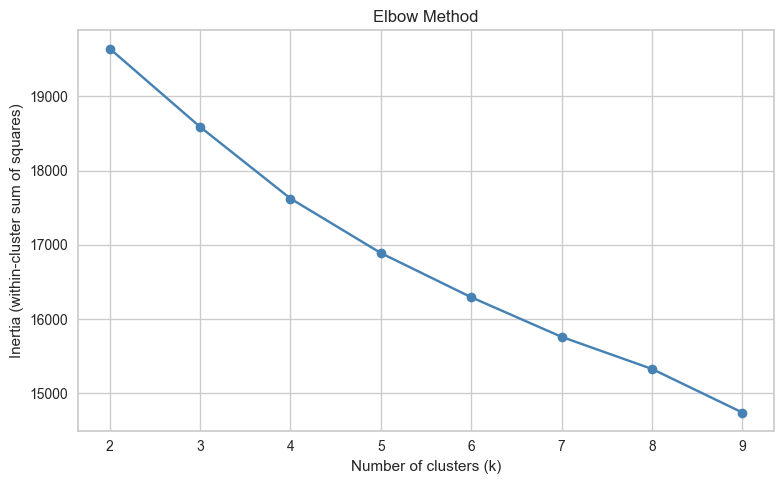

k=2: 19646.32
k=3: 18590.72
k=4: 17625.13
k=5: 16890.32
k=6: 16294.41
k=7: 15760.57
k=8: 15327.97
k=9: 14740.82


In [6]:
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('../outputs/figures/elbow.png', dpi=150, bbox_inches='tight')
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f"k={k}: {inertia:.2f}")

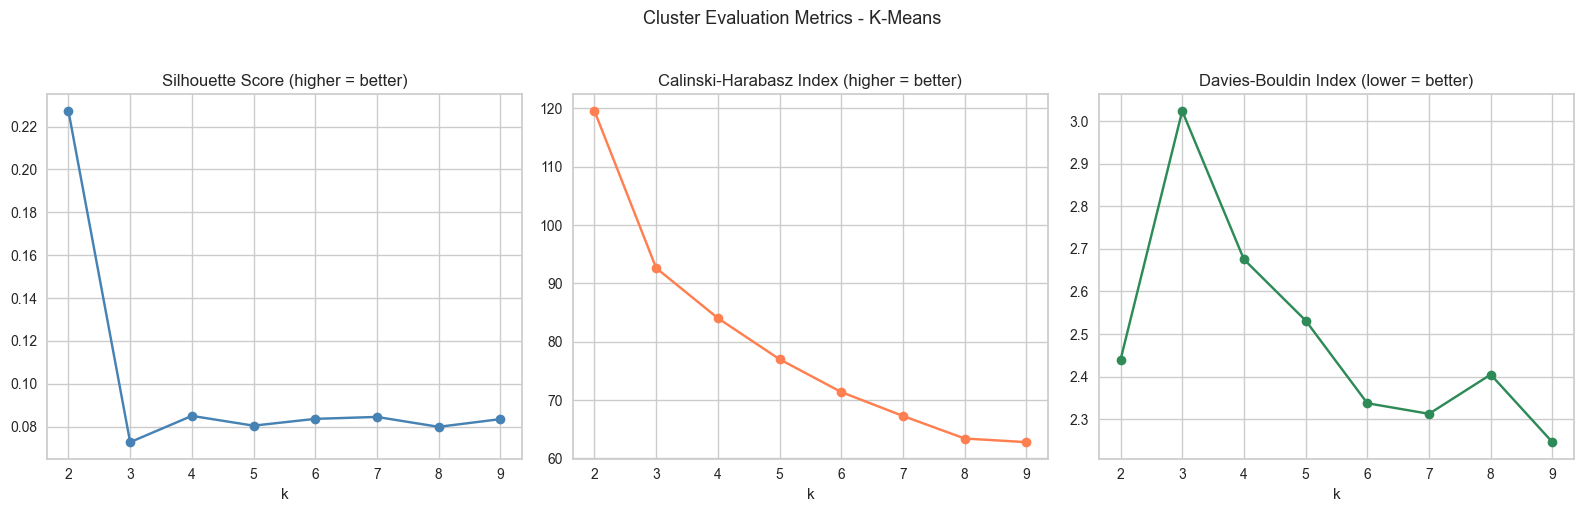

k     Silhouette      CH Index        DB Index  
2     0.2273          119.57          2.4394    
3     0.0728          92.65           3.0240    
4     0.0851          84.06           2.6754    
5     0.0805          77.01           2.5317    
6     0.0837          71.39           2.3374    
7     0.0846          67.29           2.3125    
8     0.0799          63.42           2.4048    
9     0.0835          62.80           2.2459    


In [7]:
silhouette_scores = []
ch_scores = []
db_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(k_range, silhouette_scores, marker='o', color='steelblue')
axes[0].set_title('Silhouette Score (higher = better)')
axes[0].set_xlabel('k')

axes[1].plot(k_range, ch_scores, marker='o', color='coral')
axes[1].set_title('Calinski-Harabasz Index (higher = better)')
axes[1].set_xlabel('k')

axes[2].plot(k_range, db_scores, marker='o', color='seagreen')
axes[2].set_title('Davies-Bouldin Index (lower = better)')
axes[2].set_xlabel('k')

plt.suptitle('Cluster Evaluation Metrics - K-Means', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# print the table
print(f"{'k':<5} {'Silhouette':<15} {'CH Index':<15} {'DB Index':<10}")
for k, s, ch, db in zip(k_range, silhouette_scores, ch_scores, db_scores):
    print(f"{k:<5} {s:<15.4f} {ch:<15.2f} {db:<10.4f}")

**Reading the metrics:**

The elbow chart shows almost no bend - inertia declines nearly linearly  
from K=2 to K=9. No single K stands out mathematically.

| k | Silhouette | CH Index | DB Index |
|---|---|---|---|
| 2 | **0.2273** | **119.57** | 2.4394 |
| 3 | 0.0728 | 92.65 | 3.0240 |
| 4 | 0.0851 | 84.06 | 2.6754 |
| 5 | 0.0805 | 77.01 | 2.5317 |
| 9 | 0.0835 | 62.80 | **2.2459** |

K=2 dominates silhouette and CH but produces only a coarse split.  
K=9 has the best DB but is too granular for clear policy-facing profiles.

**Decision: K=4.** It balances statistical quality and interpretability for the SME context.

## 5. K-Means at K=4

In [8]:
km = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
df['cluster'] = km.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())
print(f"\nInertia: {km.inertia_:.2f}")

Cluster sizes:
cluster
0    318
1    503
2    161
3     61
Name: count, dtype: int64

Inertia: 17625.13


### Silhouette Analysis

A per-firm silhouette plot shows how well each firm sits within its assigned  
cluster. Firms with negative scores are closer to a neighbouring cluster  
than their own - a sign of weak separation at the individual level.

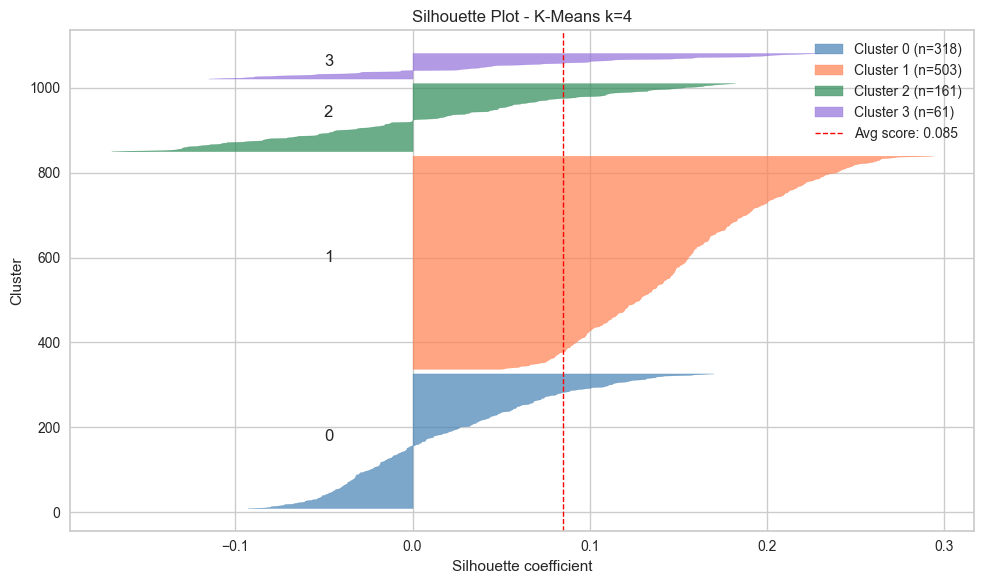


Average silhouette score: 0.0851

Per-cluster average:
  Cluster 0: 0.0171 (n=318)
  Cluster 1: 0.1554 (n=503)
  Cluster 2: 0.0118 (n=161)
  Cluster 3: 0.0526 (n=61)


In [9]:
from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(X_scaled, df['cluster'])
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
for i in range(4):
    cluster_sil_vals = np.sort(silhouette_vals[df['cluster'] == i])
    size = len(cluster_sil_vals)
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil_vals,
                     alpha=0.7, color=colors[i], label=f'Cluster {i} (n={size})')

    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, df['cluster'])
ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1,
           label=f'Avg score: {avg_score:.3f}')

ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot - K-Means k=4')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/figures/silhouette_k4.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage silhouette score: {avg_score:.4f}")
print("\nPer-cluster average:")
for i in range(4):
    vals = silhouette_vals[df['cluster'] == i]
    print(f"  Cluster {i}: {vals.mean():.4f} (n={len(vals)})")

**Reading the silhouette plot (current run):**

- Cluster 1 (n=503) is the strongest-separated group with average silhouette 0.155
- Clusters 0 (n=318) and 2 (n=161) are weaker and include many borderline firms
- Cluster 3 (n=61) is smaller and moderately separated
- Overall average silhouette is 0.085

This pattern is consistent with high-dimensional SME survey data where boundaries are real but fuzzy. We still profile clusters because centroid differences remain economically meaningful.

### 2D PCA Visualisation

Project clusters onto the first two principal components (23.3% of variance)  
to get a visual sense of how the four segments sit relative to each other.  
This is a rough picture - only 23.3% of variance is shown.

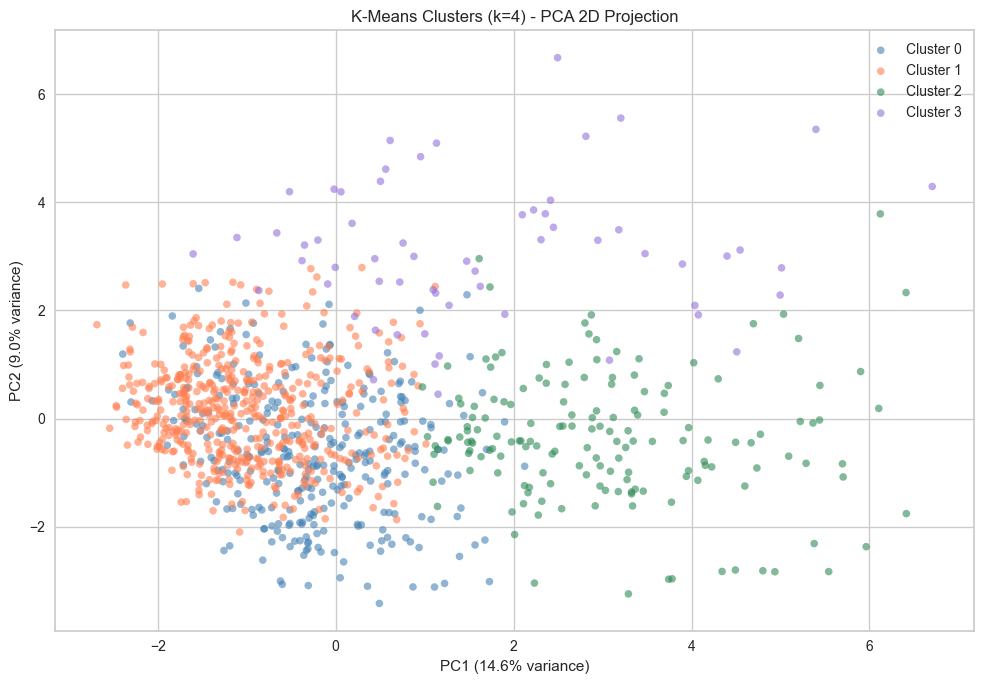

In [10]:
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
cluster_labels = df['cluster'].values

fig, ax = plt.subplots(figsize=(10, 7))

for i in range(4):
    mask = cluster_labels == i
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=colors[i], label=f'Cluster {i}',
               alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('K-Means Clusters (k=4) - PCA 2D Projection')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/clusters_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hierarchical Clustering - Independent Validation

K-Means assumes spherical clusters and is sensitive to initialisation.  
Running hierarchical clustering (Ward linkage) independently gives us a  
second view of the data structure without those assumptions.

Ward linkage minimises the total within-cluster variance at each merge step,  
making it the most comparable method to K-Means for this task.

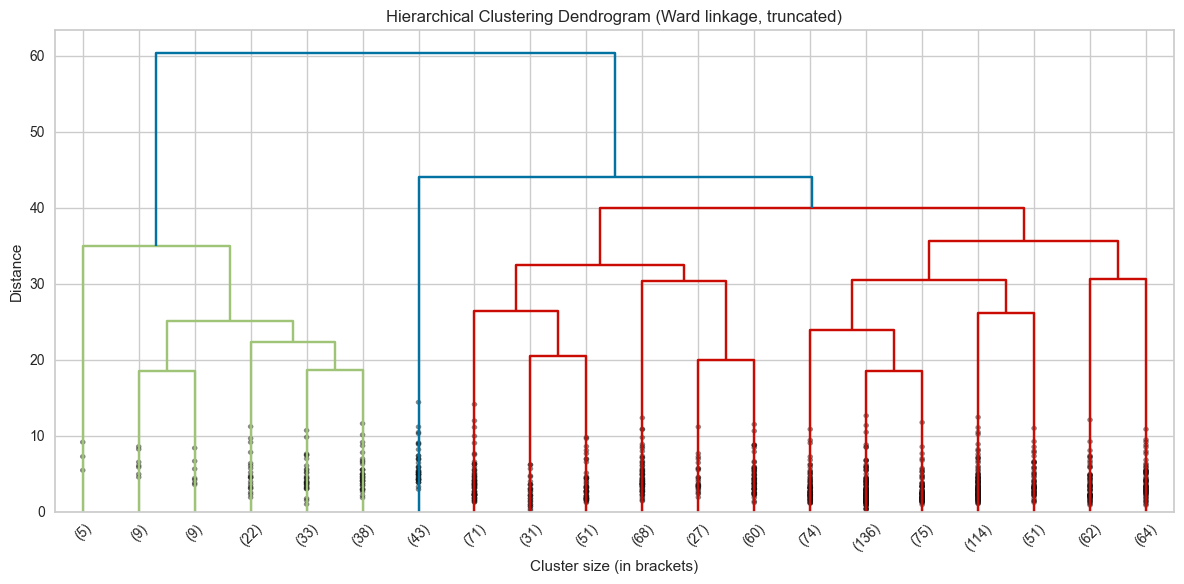

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=45,
           leaf_font_size=10,
           show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage, truncated)')
plt.xlabel('Cluster size (in brackets)')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('../outputs/figures/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster_hc'] = hc.fit_predict(X_scaled)

print("Hierarchical cluster sizes:")
print(df['cluster_hc'].value_counts().sort_index())

sil_hc = silhouette_score(X_scaled, df['cluster_hc'])
sil_km = silhouette_score(X_scaled, df['cluster'])
ch_hc = calinski_harabasz_score(X_scaled, df['cluster_hc'])
ch_km = calinski_harabasz_score(X_scaled, df['cluster'])
db_hc = davies_bouldin_score(X_scaled, df['cluster_hc'])
db_km = davies_bouldin_score(X_scaled, df['cluster'])

print(f"\n{'Metric':<25} {'K-Means':<15} {'Hierarchical':<15}")
print(f"{'Silhouette':<25} {sil_km:<15.4f} {sil_hc:<15.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_km:<15.2f} {ch_hc:<15.2f}")
print(f"{'Davies-Bouldin':<25} {db_km:<15.4f} {db_hc:<15.4f}")

Hierarchical cluster sizes:
cluster_hc
0    576
1    116
2     43
3    308
Name: count, dtype: int64

Metric                    K-Means         Hierarchical   
Silhouette                0.0851          0.0765         
Calinski-Harabasz         84.06           67.89          
Davies-Bouldin            2.6754          3.0511         


In [13]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['cluster'], df['cluster_hc'])
print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.4f}")
print("(1.0 = perfect agreement, 0.0 = random)")

Adjusted Rand Index (K-Means vs Hierarchical): 0.3342
(1.0 = perfect agreement, 0.0 = random)


**Reading the results (current run):**

The dendrogram still supports a 4-cluster cut as a reasonable partitioning choice.

**Metric comparison:**

| Metric | K-Means | Hierarchical |
|---|---|---|
| Silhouette | **0.0851** | 0.0765 |
| Calinski-Harabasz | **84.06** | 67.89 |
| Davies-Bouldin | **2.6754** | 3.0511 |

K-Means remains better on all three evaluation metrics.

**ARI = 0.3342** indicates moderate agreement between methods. Both methods detect a dominant mass plus smaller differentiated groups, but differ on how middle-density firms are partitioned.

**Decision:** Keep K-Means at K=4 as the primary segmentation.

## 7. Cluster Profiling

With K=4 confirmed, we now compute the mean feature values per cluster  
to understand what each segment actually looks like. This is where the  
statistical output becomes a business story.

In [14]:
# use K-Means labels as the primary result
profile = df.drop(columns=['cluster_hc']).groupby('cluster').mean().round(3)

# infer semantic segment names from profile each run (same logic as src/cluster.py)
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))
from src.cluster import SEGMENT_NAMES, infer_segment_name_map

segment_map, segment_scores = infer_segment_name_map(profile)
df['segment'] = df['cluster'].map(segment_map)

# reorder profile by semantic segment order for reporting and plots
segment_order = [name for name in SEGMENT_NAMES if name in df['segment'].unique()]
profile_by_segment = (
    df.drop(columns=['cluster_hc'])
      .groupby('segment')
      .mean()
      .reindex(segment_order)
      .round(3)
)

print('Inferred cluster -> segment mapping:')
for cluster_id in sorted(segment_map):
    print(f'  {cluster_id} -> {segment_map[cluster_id]}')

print('\nSegment sizes:')
print(df['segment'].value_counts())

# transpose for readability
profile_by_segment.T

Inferred cluster -> segment mapping:
  0 -> Domestic Mid-Tier
  1 -> Constrained Micro Firms
  2 -> Formal Export Leaders
  3 -> Credit-Reliant Traders

Segment sizes:
segment
Constrained Micro Firms    503
Domestic Mid-Tier          318
Formal Export Leaders      161
Credit-Reliant Traders      61
Name: count, dtype: int64


segment,Credit-Reliant Traders,Formal Export Leaders,Domestic Mid-Tier,Constrained Micro Firms
l1,3.671,4.687,2.821,2.673
k3a,46.148,83.323,57.928,79.076
k3bc,32.951,2.019,0.292,0.358
k3f,8.361,5.217,13.126,4.453
d3c,2.377,5.609,0.723,0.080
d12b,30.246,32.453,10.535,8.205
b5,2003.164,1990.696,2006.198,2009.795
b7,2.961,2.902,2.926,2.598
k82a,0.803,0.174,0.079,0.068
b8,0.180,0.621,0.013,0.010


In [15]:
# pull sector and region from raw data and join to segmented output
df_raw = pd.read_stata('../data/raw/Nigeria-2025-full-data.dta')
df_meta = df_raw[['stratificationsectorcode', 'stratificationregioncode']].copy()
df_seg = pd.read_csv('../data/processed/sme_segmented.csv')

# confirm row count matches before joining - both must be 1,043 in same order
assert len(df_seg) == len(df_meta), f"Row count mismatch: {len(df_seg)} vs {len(df_meta)}"

df_enriched = pd.concat([df_seg, df_meta.reset_index(drop=True)], axis=1)

# sector distribution per segment - shows which industries each segment draws from
print("Sector distribution per segment (row proportions):")
print(pd.crosstab(df_enriched['segment'], df_enriched['stratificationsectorcode'], normalize='index').round(2))

print("\nRegion distribution per segment (row proportions):")
print(pd.crosstab(df_enriched['segment'], df_enriched['stratificationregioncode'], normalize='index').round(2))

stratificationsectorcode  Food  Garments  Fabricated Metals  \
segment                                                       
Constrained Micro Firms   0.10      0.13               0.10   
Credit-Reliant Traders    0.11      0.02               0.13   
Domestic Mid-Tier         0.12      0.16               0.11   
Formal Export Leaders     0.18      0.01               0.11   

stratificationsectorcode  Other Manufacturing  Professional Activities  \
segment                                                                  
Constrained Micro Firms                  0.09                     0.18   
Credit-Reliant Traders                   0.13                     0.15   
Domestic Mid-Tier                        0.10                     0.12   
Formal Export Leaders                    0.25                     0.11   

stratificationsectorcode  Retail  Other Services  
segment                                           
Constrained Micro Firms     0.14            0.25  
Credit-Reliant Traders 

**What to look for in these tables:**

Each row shows the proportion of firms in that segment across sectors and regions.  
Values add up to 1.0 across each row.

- Sector concentration tells us whether a segment is dominated by a particular industry  
  - for example, if Formal Export Leaders skew toward Manufacturing that confirms the profile
- Regional concentration tells us whether segments reflect geography as much as firm behaviour  
  - the South West has 344 of 1,043 firms (33%) so some concentration there is expected

**Sampling note:** This is a stratified sample designed by the World Bank to represent  
formal Nigerian SMEs across region, size, and sector. The South West is intentionally  
over-represented relative to other regions because it has the densest formal firm population.  
Interpret regional distributions with that in mind.

**Segment profiles from current run (semantic labels inferred from profile patterns):**

**Constrained Micro Firms (n=503)**  
Largest group. Mostly domestic-facing (low exports/import intensity) with very low formal capability signals and the highest obstacle ratings (finance/electricity/informality). This is the constraint-heavy base of the market.

**Domestic Mid-Tier (n=318)**  
Middle-sized domestic firms with low credit dependence and relatively lower obstacle intensity. More stable than micro firms, but still not strongly export-led.

**Formal Export Leaders (n=161)**  
Most internationally connected and capability-rich segment: highest exports, foreign input use, quality certifications, website presence, and foreign technology adoption.

**Credit-Reliant Traders (n=61)**  
Smallest segment but most credit-intensive: very high bank borrowing and loan access, with meaningful trade exposure. Strong dependence on external finance defines this group.

### Radar Charts

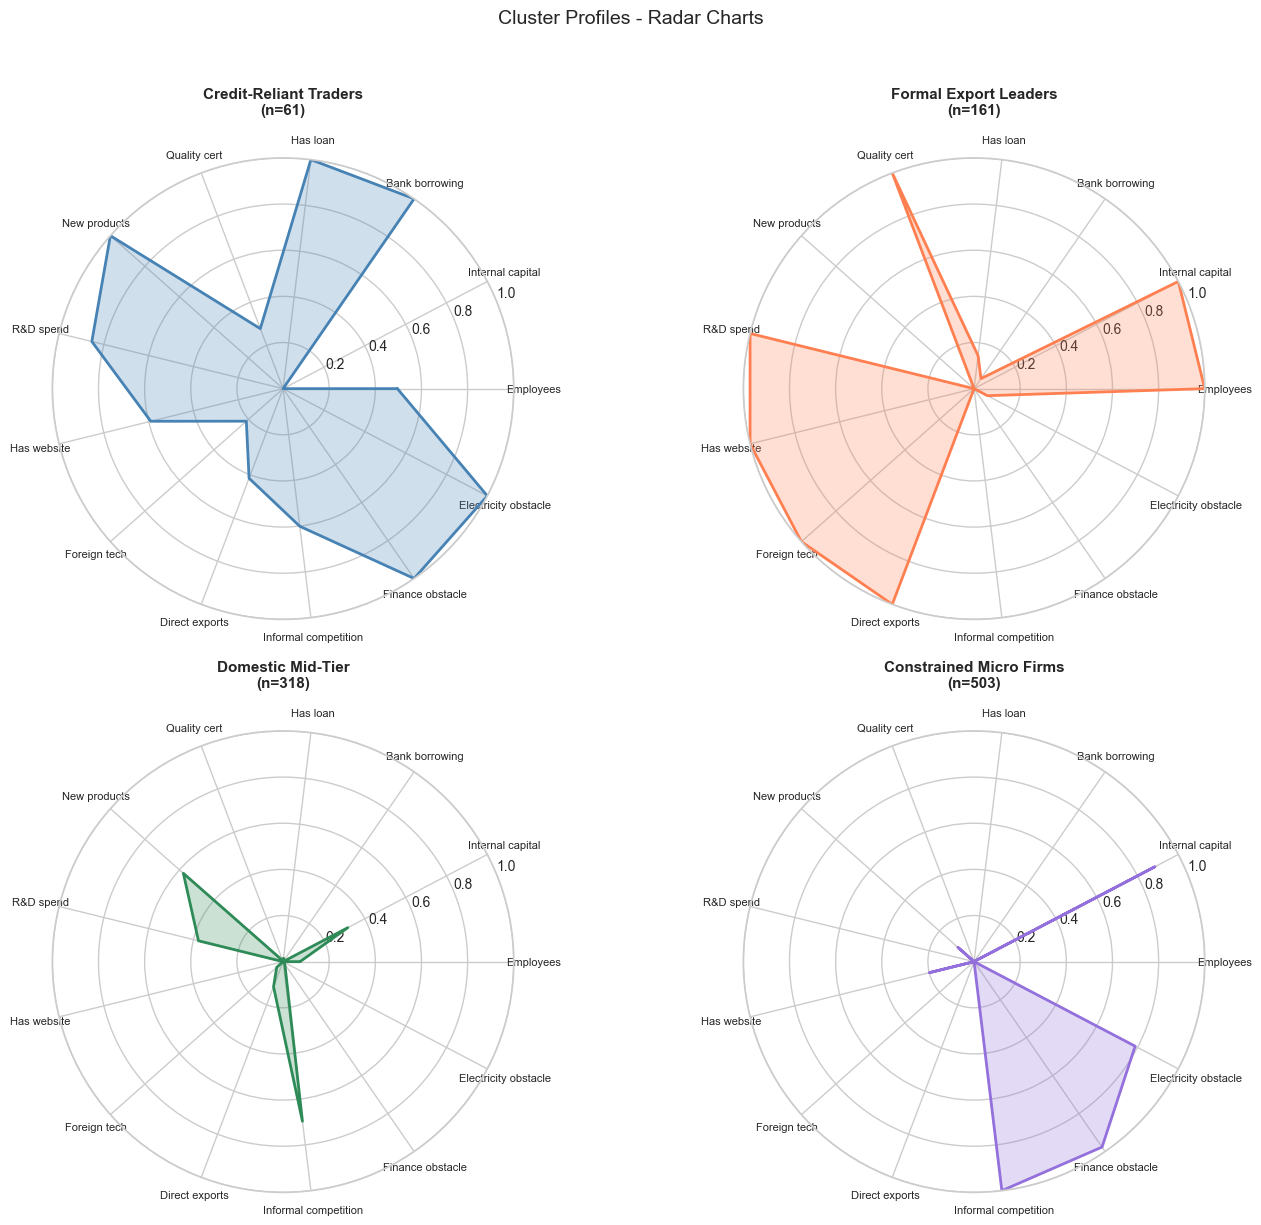

In [16]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# select the most interpretable features for the radar
radar_features = ['l1', 'k3a', 'k3bc', 'k82a', 'b8', 'h1', 
                  'h8', 'c22b', 'e6', 'd3c', 'e11', 'k30', 'c30a']

radar_labels = ['Employees', 'Internal capital', 'Bank borrowing',
                'Has loan', 'Quality cert', 'New products',
                'R&D spend', 'Has website', 'Foreign tech',
                'Direct exports', 'Informal competition',
                'Finance obstacle', 'Electricity obstacle']

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

# normalise to 0-1 for radar
profile_radar = profile_by_segment[radar_features].copy()
profile_radar = (profile_radar - profile_radar.min()) / (profile_radar.max() - profile_radar.min()).replace(0, 1)

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()
segment_sizes = df['segment'].value_counts()

for i, (segment_name, row) in enumerate(profile_radar.iterrows()):
    ax = axes[i]
    values = row.tolist()
    values += values[:1]

    ax.plot(angles, values, color=colors[i % len(colors)], linewidth=2)
    ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=8)
    ax.set_title(f'{segment_name}\n(n={segment_sizes.get(segment_name, 0)})',
                 size=11, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

for j in range(len(profile_radar), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cluster Profiles - Radar Charts', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/radar_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

The radar charts now read best by **segment name** (not raw cluster ID):

- **Credit-Reliant Traders** spike on borrowing/loan intensity
- **Formal Export Leaders** spike on export and formality/technology dimensions
- **Domestic Mid-Tier** show moderate domestic operating features with lower stress
- **Constrained Micro Firms** show elevated constraint scores with thinner capability signals

### Key Feature Comparison

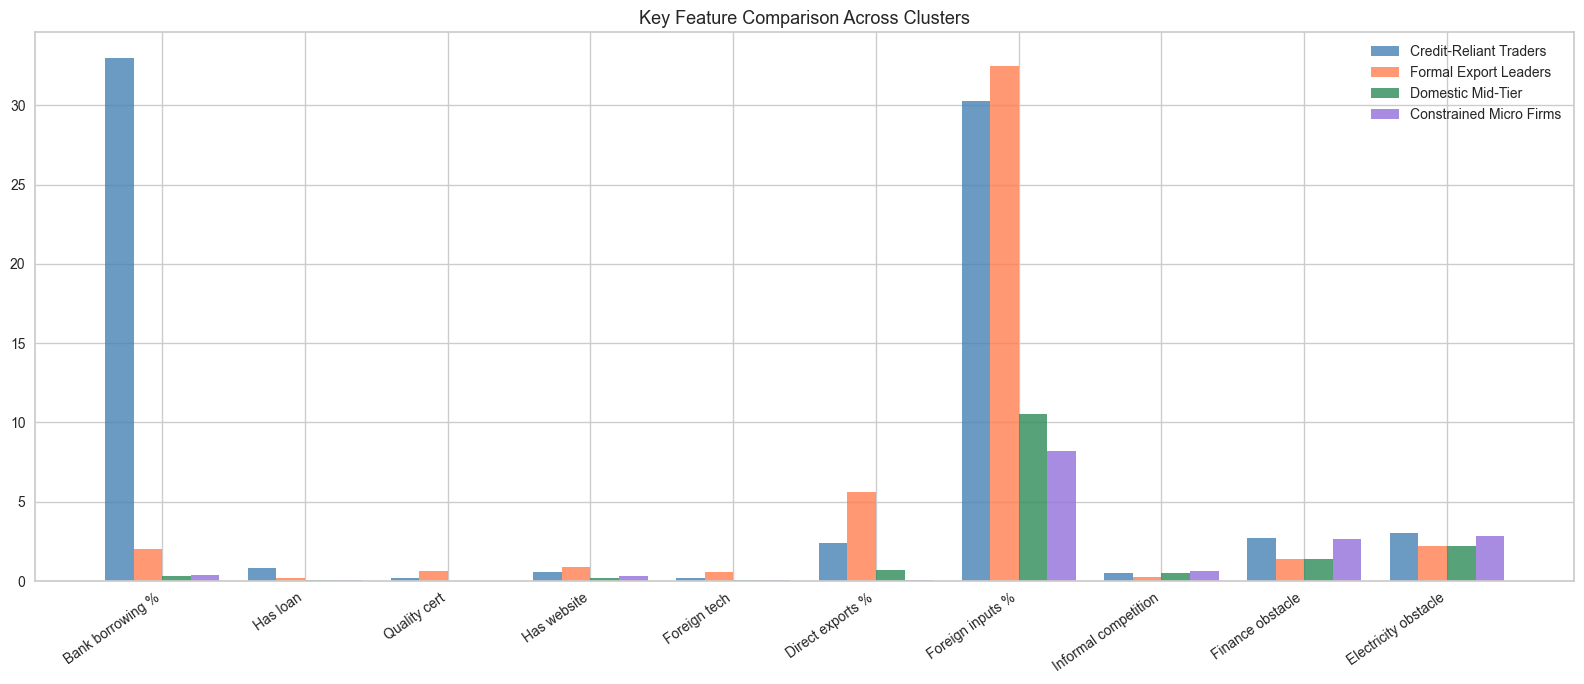

In [17]:
key_features = ['k3bc', 'k82a', 'b8', 'c22b', 'e6', 'd3c', 'd12b', 'e11', 'k30', 'c30a']
key_labels = ['Bank borrowing %', 'Has loan', 'Quality cert', 'Has website',
              'Foreign tech', 'Direct exports %', 'Foreign inputs %',
              'Informal competition', 'Finance obstacle', 'Electricity obstacle']

x = np.arange(len(key_features))
n_segments = len(profile_by_segment.index)
width = 0.8 / max(n_segments, 1)
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(16, 7))

for i, segment_name in enumerate(profile_by_segment.index):
    vals = [profile_by_segment.loc[segment_name][f] for f in key_features]
    ax.bar(x + i * width, vals, width, label=segment_name, color=colors[i % len(colors)], alpha=0.8)

ax.set_xticks(x + width * (n_segments - 1) / 2)
ax.set_xticklabels(key_labels, rotation=35, ha='right')
ax.set_title('Key Feature Comparison Across Clusters', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/cluster_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The grouped bar chart separates segments clearly:

- **Credit-Reliant Traders** stand out on bank borrowing and loan access
- **Formal Export Leaders** lead on direct exports, foreign inputs, certifications, websites, and foreign tech
- **Constrained Micro Firms** carry the highest obstacle burden
- **Domestic Mid-Tier** sit between the top exporters and the most constrained firms

## 8. Save Labelled Dataset

For reproducibility in scripts, segment naming is now handled dynamically from cluster profiles before export (to avoid fixed ID-name mismatches).

In [18]:
# segment labels are already inferred dynamically from cluster profiles above
if 'segment' not in df.columns:
    df['segment'] = df['cluster'].map(segment_map)

df.to_csv('../data/processed/sme_segmented.csv', index=False)

print('Saved to data/processed/sme_segmented.csv')
print(df['segment'].value_counts())

Saved to data/processed/sme_segmented.csv
segment
Constrained Micro Firms    503
Domestic Mid-Tier          318
Formal Export Leaders      161
Credit-Reliant Traders      61
Name: count, dtype: int64


## Summary

**Current run segments (profile-inferred naming):**

| Segment | n | Share | Key characteristic |
|---|---|---|---|
| Constrained Micro Firms | 503 | 48.2% | Largest group, low capability, highest constraints |
| Domestic Mid-Tier | 318 | 30.5% | Domestic core, moderate scale, lower stress |
| Formal Export Leaders | 161 | 15.4% | Export and capability-intensive segment |
| Credit-Reliant Traders | 61 | 5.8% | Small but highly credit-dependent trading firms |

These numbers are stable - same raw data, same `random_state=42`, same pipeline  
always produces the same cluster assignments and the same inferred segment names.

**Methodology decisions:**

| Decision | Reason |
|---|---|
| Full features for clustering | PCA showed no dominant axis - 14.4% on PC1 |
| PCA used for 2D visualisation only | 2 components explain only 23.3% of variance |
| K=4 selected | Best balance of metrics and interpretability |
| K-Means preferred over hierarchical | Better silhouette, CH, and DB scores |
| Dynamic segment naming | Prevents semantic label drift when cluster IDs swap between runs |
| Sector and region enrichment | Adds real-world context beyond feature means |